# Описание задания:
Поздравляем! Вы успешно прошли стажировку, помогли коллегам с исследованием и определили фактор, влияющий на стратегию компании. Вас взяли в одно из подразделений группы компаний, вы — аналитик крупного агрегатора такси. Теперь перед вами стоит важная задача: самостоятельно провести исследование данных, проверить гипотезу о поведенческом предпочтении пользователей определённого класса такси и сделать выводы, чтобы помочь компании стать лучшей на рынке. Успехов!

1. Используйте датасет FPS_hw_x_df_x_taxi.xlsxКак работать с файлом.
2. Исследуйте данные и постройте графики плотности распределения дистанций поездок для классов Economy и Comfort.
3. Проверьте гипотезу: «На дальние поездки пользователи предпочитают Economy-классу более комфортные условия поездки в Comfort-классе».
4. Сделайте выводы по результатам проверки. Для определения предпочтений понадобится изучение описательных статистик и графиков по классам.

Примечание: гипотезы всегда формулируются однозначно, поскольку не уточняется конкретное значение дистанций, а просто сказано “дальние” и нет уточнений по статусу поездки, необходимо исследовать общее распределение.

## Критерии оценки задания:

- Вычислены описательные статистики.
- Построено распределение задействованных в гипотезе данных.
- Проведена проверка гипотезы соответствующим статистическим критерием.
- Сделаны выводы по результатам проверки.

## Описание датасета:
### Датасет содержит информацию о заказах такси одного из известных агрегаторов:

- order_gk — идентификатор поездки;
- weekday_key — день недели совершения поездки;
- hour_key — час совершения поездки (в системном формате);
- distance_km — дистанция поездки;
- offer_class_group — класс поездки (Economy, Comfort, Premium, Delivery);
- driver_response — статус поездки (1 — поездка совершена; 0 — отмена).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

alpha = 0.05

In [2]:
df = pd.read_excel('FPS_hw_x_df_x_taxi.xlsx')
df.head(5)

,order_gk,weekday_key,hour_key,distance_km,offer_class_group,driver_response
0,412,7,22.967881,53.113626,Premium,1
1,436,3,19.439948,5.781342,Delivery,1
2,1327,6,19.816643,16.200071,Delivery,0
3,2013,2,19.123837,13.731643,Delivery,0
4,2241,6,23.164958,20.436380,Premium,1


In [3]:
display(df.describe())
display(df['offer_class_group'].unique())

,order_gk,weekday_key,hour_key,distance_km,driver_response
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,462807.384000,4.044000,21.520472,26.275849,0.587000
std,270556.211847,2.007256,4.355491,18.876337,0.492496
min,412.000000,1.000000,14.899553,0.024259,0.000000
25%,227126.500000,2.000000,18.466897,12.176830,0.000000
50%,458637.000000,4.000000,20.414741,22.828544,1.000000
75%,709420.250000,6.000000,23.497139,36.434558,1.000000
max,919196.000000,7.000000,50.206056,138.950082,1.000000


<StringArray>
['Premium', 'Delivery', 'Comfort', 'Economy']
Length: 4, dtype: str

In [4]:
df_eco = df[df['offer_class_group'] == 'Economy'].copy()
df_comf = df[df['offer_class_group'] == 'Comfort'].copy()
print('Выборкки имеют одинаковую длинну: ', len(df_eco) == len(df_comf))

Выборкки имеют одинаковую длинну:  True


In [5]:
# Описательные статистики такси тариф Эконом
df_eco.describe()

,order_gk,weekday_key,hour_key,distance_km,driver_response
count,500.00000,500.000000,500.000000,500.000000,500.000000
mean,463448.91200,3.896000,22.165311,26.283117,0.422000
std,274029.66119,1.989246,4.063839,17.016153,0.494373
min,3845.00000,1.000000,14.899553,0.089947,0.000000
25%,226962.50000,2.000000,19.006174,13.372229,0.000000
50%,455884.50000,4.000000,21.257715,23.798183,0.000000
75%,721415.75000,6.000000,24.402652,36.845287,1.000000
max,919196.00000,7.000000,39.185553,90.516618,1.000000


In [6]:
# Описательные статистики такси тариф Комфорт
df_comf.describe()

,order_gk,weekday_key,hour_key,distance_km,driver_response
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,465289.002000,4.106000,22.943699,29.758910,0.486000
std,272443.226582,1.968378,4.842951,17.644643,0.500305
min,2710.000000,1.000000,15.496198,0.024259,0.000000
25%,232141.250000,2.000000,19.430402,16.345205,0.000000
50%,475479.000000,4.000000,21.704980,28.078273,0.000000
75%,697329.750000,6.000000,25.120825,41.300650,1.000000
max,918656.000000,7.000000,50.206056,81.507022,1.000000


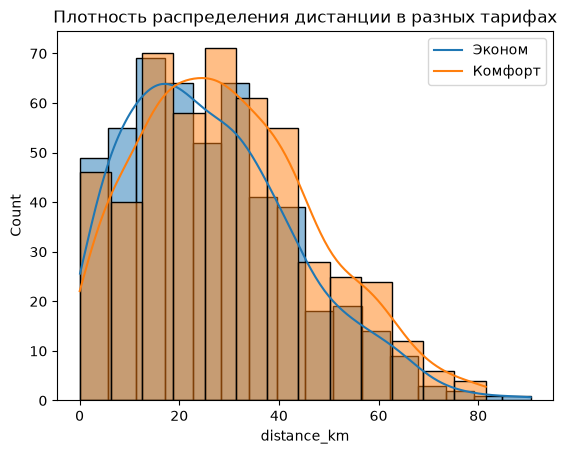

In [7]:
sns.histplot(df_eco['distance_km'], kde=True)
sns.histplot(df_comf['distance_km'], kde=True)
plt.title('Плотность распределения дистанции в разных тарифах')
plt.legend(['Эконом', 'Комфорт'])
plt.show()

### Гипотезы
- H0: Средняя дистанция поездок Economy и Comfort не различается
- H1: Средняя дистанция поездок Economy и Comfort различается

In [13]:
result = ttest_ind(df_eco['distance_km'], df_comf['distance_km'])
print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Отвергаем H0 — средние дистанции различаются')
else:
    print('Не отвергаем H0 — нет оснований считать, что средние различаются')

p-value: 0.0015675100297112723
Отвергаем H0 — средние дистанции различаются


In [14]:
print(f"Средняя дистанция Economy: {df_eco['distance_km'].mean():.2f} км")
print(f"Средняя дистанция Comfort: {df_comf['distance_km'].mean():.2f} км")

Средняя дистанция Economy: 26.28 км
Средняя дистанция Comfort: 29.76 км


## Вывод

T-тест показал статистически значимые различия между средней дистанцией поездок Economy и Comfort (p-value= 0.0016 < alpha = 0.05).
Средняя дистанция для Economy составила 26.28 км, для Comfort - 29.76 км. Это означает, что в среднем поездки на Comfort на 3.48 км длиннее.
Гипотеза о том, что на дальние поездки пользователи предпочитают Comfort по отношению Economy, подтверждается.
Графики плотности распределения показывают смещение распределения Comfort вправо (в сторону больших дистанций), что согласуется с результатами теста.